In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

  Activating project at `~/Desktop/longitudinal_dynamics`


In [2]:
using LongitudinalTomography
using CairoMakie
using Random
using Zygote
using Printf

CairoMakie.activate!()

In [3]:
# Recycler Parameters
const PROTON_MASS_EV = 938.2720813e6

kinetic_energy_eV = 8.0e9
total_energy_eV = kinetic_energy_eV + PROTON_MASS_EV
gamma_s = total_energy_eV / PROTON_MASS_EV
beta_s = sqrt(1 - 1 / gamma_s^2)

machine = SingleRFMachine(
    harmonic=588,
    f_rev_hz=89.8e3,
    eta0=-0.00871573,
    beta_s=beta_s,
    E_s_eV=total_energy_eV,
    rf_kick_eV=80.0e3,
    phi_s=0.0,
    delta_t_s=0.0,
)

@printf("Q_s                    = %.7f\n", synchrotron_tune(machine))
@printf("synchrotron period     = %.2f turns\n", synchrotron_period_turns(machine))
@printf("bucket half-width      = %.3f ns\n", bucket_half_width_s(machine) * 1e9)
@printf("bucket half-height     = %.3f MeV\n", bucket_half_height_eV(machine) * 1e-6)

Q_s                    = 0.0027169
synchrotron period     = 368.07 turns
bucket half-width      = 9.469 ns
bucket half-height     = 9.373 MeV


In [4]:
# ## Smooth synthetic initial distribution inside the separatrix
#
# The latent variables are Gaussian, but the final transformation is smooth and
# bounded:
#
#     theta = pi*tanh(u)
#     P = 2*rho*cos(theta/2)*tanh(v),  rho < 1.
#
# This guarantees every particle is inside the stationary separatrix.
rng = MersenneTwister(42)
n_particles = 4096
correlation = 0.55

z1 = randn(rng, n_particles)
z2 = randn(rng, n_particles)

# Initiate particles within separatrix 
u = 0.24 .* z1
v = 0.32 .* (
    correlation .* z1 .+
    sqrt(1 - correlation^2) .* z2
)

theta0, P0 = trapped_coordinates(u, v; momentum_fraction=0.92)
@assert all(inside_separatrix(theta0, P0; margin=1e-12))

delta_t0_s = delta_t_from_theta(theta0, machine)
delta_E0_eV = delta_energy_from_P(P0, machine)


4096-element Vector{Float64}:
      -1.2203234929209289e6
  245422.65380207452
       1.2197231608364885e6
      -3.0715385221205414e6
       2.469631623558513e6
      -1.708833546947219e6
 -976660.0476257998
       3.5102599526825356e6
  860066.1574712974
       2.4191065910689034e6
       1.9690839767308242e6
       3.9008427829584284e6
      -3.1740414904986443e6
       ⋮
      -1.9886984821494427e6
  339559.1419683241
      -2.8972474636906837e6
 -237713.67469695339
      -4.489942647014418e6
       2.529277117860689e6
      -1.413010690338687e6
       2.4677814731145795e6
       2.226473771598067e6
      -3.100724923483279e6
  219589.17781302493
  202298.74045040764

In [5]:
# ## Differentiable forward projection
#
# We use 51 profiles from turn 0 through turn 250. The 75 time-bin centers span
# one RF bucket, approximately 18.9 ns. `soft_sigma_s` controls the Gaussian
# soft-assignment width and can later be matched to the effective RWCM time
# resolution.

turns = collect(0.0:5.0:500.0)

half_width_s = bucket_half_width_s(machine)
n_time_bins = 75
time_bin_centers_s = collect(range(
    machine.delta_t_s - half_width_s,
    machine.delta_t_s + half_width_s;
    length=n_time_bins,
))
time_bin_spacing_s = time_bin_centers_s[2] - time_bin_centers_s[1]
soft_sigma_s = 0.75 * time_bin_spacing_s

cascade = predict_rwcm_cascade(
    theta0,
    P0,
    turns,
    machine,
    time_bin_centers_s;
    sigma=soft_sigma_s,
)

@printf("particles               = %d\n", n_particles)
@printf("profiles                = %d\n", length(turns))
@printf("time bins               = %d\n", n_time_bins)
@printf("time-bin spacing        = %.3f ns\n", time_bin_spacing_s * 1e9)
@printf("soft histogram sigma    = %.3f ns\n", soft_sigma_s * 1e9)
@printf(
    "largest normalization error = %.3e\n",
    maximum(abs.(sum(cascade.profiles; dims=2) .- 1)),
)

particles               = 4096
profiles                = 101
time bins               = 75
time-bin spacing        = 0.256 ns
soft histogram sigma    = 0.192 ns
largest normalization error = 6.661e-16


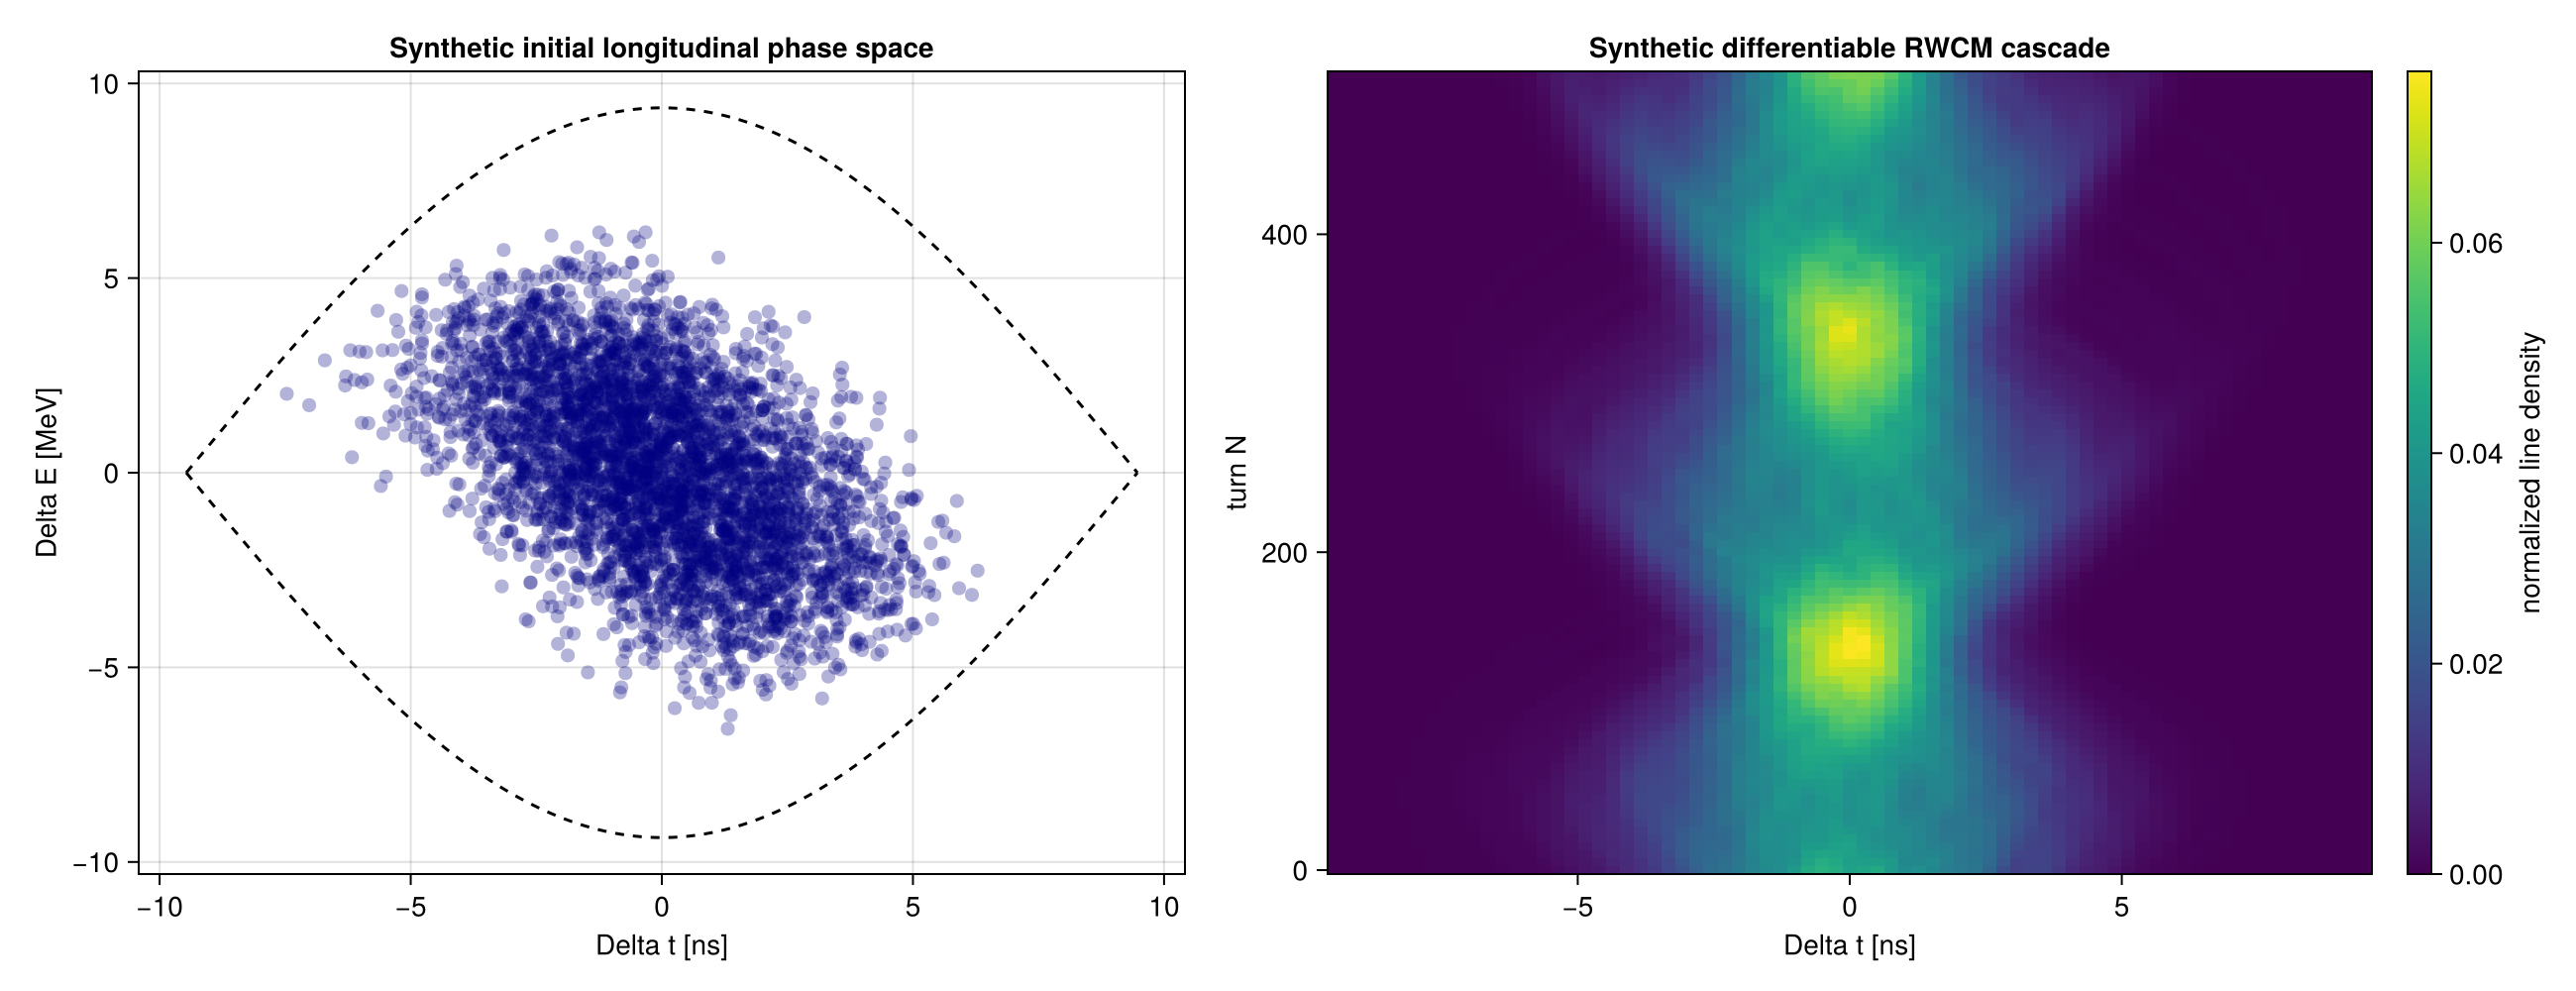

CairoMakie.Screen{IMAGE}


In [6]:
figure = Figure(size=(1300, 500))

axis_initial = Axis(
    figure[1, 1];
    xlabel="Delta t [ns]",
    ylabel="Delta E [MeV]",
    title="Synthetic initial longitudinal phase space",
)

theta_sep = range(-pi, pi; length=1200)
P_sep = 2 .* cos.(theta_sep ./ 2)
delta_t_sep_ns = delta_t_from_theta(theta_sep, machine) .* 1e9
delta_E_sep_1_MeV = delta_energy_from_P(P_sep, machine) .* 1e-6
delta_E_sep_2_MeV = delta_energy_from_P(-P_sep, machine) .* 1e-6

lines!(
    axis_initial,
    delta_t_sep_ns,
    delta_E_sep_1_MeV;
    color=:black,
    linestyle=:dash,
    linewidth=1.5,
)
lines!(
    axis_initial,
    delta_t_sep_ns,
    delta_E_sep_2_MeV;
    color=:black,
    linestyle=:dash,
    linewidth=1.5,
)
scatter!(
    axis_initial,
    delta_t0_s .* 1e9,
    delta_E0_eV .* 1e-6;
    markersize=10,
    color=(:navy, 0.3),
)

axis_cascade = Axis(
    figure[1, 2];
    xlabel="Delta t [ns]",
    ylabel="turn N",
    title="Synthetic differentiable RWCM cascade",
)

heatmap_object = heatmap!(
    axis_cascade,
    time_bin_centers_s .* 1e9,
    turns,
    permutedims(cascade.profiles);
    colormap=:viridis,
)
Colorbar(figure[1, 3], heatmap_object; label="normalized line density")

display(figure)

# Uncomment to save the figure beside this notebook.
# save(joinpath(@__DIR__, "phase1_synthetic_forward_model.png"), figure)

In [7]:
# ## End-to-end differentiability demonstration
#
# The scalar below shifts the unconstrained latent coordinate. The gradient
# propagates through the trapped-particle map, Jacobi elliptic solution, BLonD
# coordinate conversion, and soft histogram. A smaller subset is used here to
# keep this diagnostic quick and memory-friendly on a laptop.

gradient_particle_indices = 1:256
gradient_turns = turns[1:5:end]
u_gradient = u[gradient_particle_indices]
v_gradient = v[gradient_particle_indices]

target_theta, target_P = trapped_coordinates(
    u_gradient .+ 0.04,
    v_gradient;
    momentum_fraction=0.92,
)
target_profiles = predict_rwcm_cascade(
    target_theta,
    target_P,
    gradient_turns,
    machine,
    time_bin_centers_s;
    sigma=soft_sigma_s,
    check=false,
).profiles

function profile_loss(latent_shift)
    theta, P = trapped_coordinates(
        u_gradient .+ latent_shift,
        v_gradient;
        momentum_fraction=0.92,
    )
    prediction = predict_rwcm_cascade(
        theta,
        P,
        gradient_turns,
        machine,
        time_bin_centers_s;
        sigma=soft_sigma_s,
        check=false,
    ).profiles
    return sum(abs2, prediction .- target_profiles)
end

loss_at_zero = profile_loss(0.0)
gradient_at_zero = only(Zygote.gradient(profile_loss, 0.0))

@printf("demonstration loss      = %.6e\n", loss_at_zero)
@printf("d(loss)/d(latent shift) = %.6e\n", gradient_at_zero)


demonstration loss      = 2.483218e-02
d(loss)/d(latent shift) = -8.891505e-01


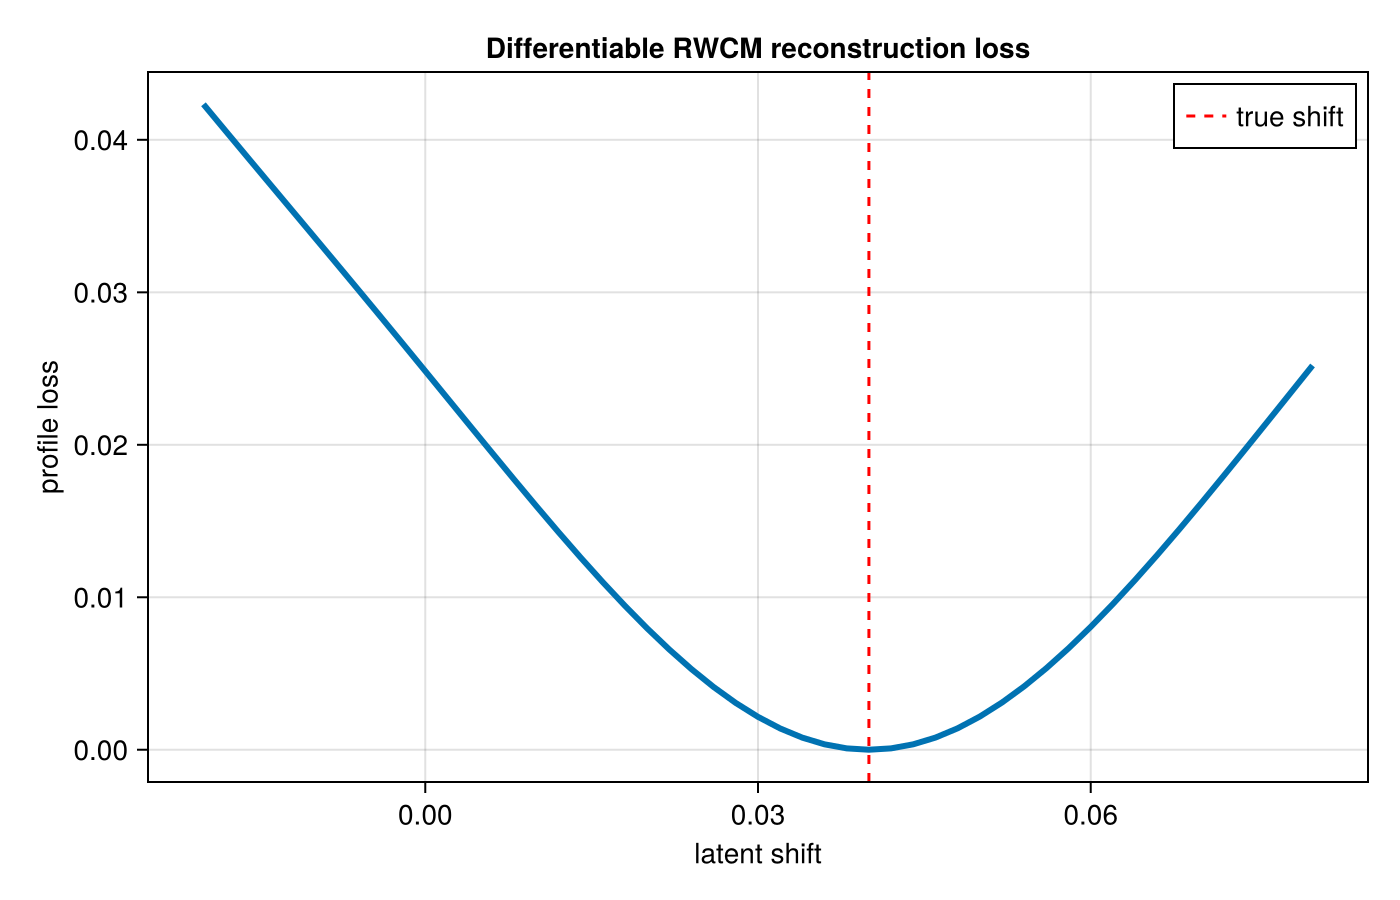

CairoMakie.Screen{IMAGE}


In [8]:
test_shifts = range(-0.02, 0.08; length=51)
test_losses = [profile_loss(s) for s in test_shifts]

fig = Figure(size=(700, 450))
ax = Axis(
    fig[1, 1];
    xlabel="latent shift",
    ylabel="profile loss",
    title="Differentiable RWCM reconstruction loss",
)

lines!(ax, test_shifts, test_losses; linewidth=3)
vlines!(ax, [0.04]; color=:red, linestyle=:dash, label="true shift")
axislegend(ax)

display(fig)

In [9]:
using Test

const PROTON_MASS_EV = 938.2720813e6
const TOTAL_ENERGY_EV = 8.0e9 + PROTON_MASS_EV
const GAMMA_S = TOTAL_ENERGY_EV / PROTON_MASS_EV
const BETA_S = sqrt(1 - 1 / GAMMA_S^2)

machine = SingleRFMachine(
    harmonic=588,
    f_rev_hz=89.8e3,
    eta0=-8.8e-3,
    beta_s=BETA_S,
    E_s_eV=TOTAL_ENERGY_EV,
    rf_kick_eV=60e3,
)

@testset "Phase-1 synthetic forward model" begin
    rng = MersenneTwister(1234)
    n_particles = 64
    z1 = randn(rng, n_particles)
    z2 = randn(rng, n_particles)
    u = 0.24 .* z1
    v = 0.32 .* (0.55 .* z1 .+ sqrt(1 - 0.55^2) .* z2)
    theta0, P0 = trapped_coordinates(u, v; momentum_fraction=0.92)

    @test all(inside_separatrix(theta0, P0; margin=1e-12))

    turns = collect(0.0:25.0:250.0)
    tau = tau_from_turn(turns, machine)
    trajectory = libration_transport(theta0, P0, tau)

    @test size(trajectory.theta) == (length(turns), n_particles)
    @test size(trajectory.P) == size(trajectory.theta)
    @test maximum(abs.(trajectory.theta[1, :] .- theta0)) < 2e-9
    @test maximum(abs.(trajectory.P[1, :] .- P0)) < 2e-9

    energy_over_time = pendulum_energy(trajectory.theta, trajectory.P)
    energy_reference = reshape(trajectory.energy, 1, n_particles)
    @test maximum(abs.(energy_over_time .- energy_reference)) < 2e-9

    half_width = bucket_half_width_s(machine)
    time_bins = collect(range(-half_width, half_width; length=41))
    sigma = 0.65 * (time_bins[2] - time_bins[1])
    cascade = predict_rwcm_cascade(
        theta0,
        P0,
        turns,
        machine,
        time_bins;
        sigma=sigma,
    )

    @test size(cascade.profiles) == (length(turns), length(time_bins))
    @test maximum(abs.(sum(cascade.profiles; dims=2) .- 1)) < 1e-12
    @test all(isfinite, cascade.profiles)

    # End-to-end gradient check: unconstrained latent shift -> trapped particles
    # -> elliptic transport -> soft histogram -> scalar profile loss.
    target_theta, target_P = trapped_coordinates(u .+ 0.035, v; momentum_fraction=0.92)
    target = predict_rwcm_cascade(
        target_theta,
        target_P,
        turns,
        machine,
        time_bins;
        sigma=sigma,
        check=false,
    ).profiles

    function loss(latent_shift)
        theta, P = trapped_coordinates(u .+ latent_shift, v; momentum_fraction=0.92)
        prediction = predict_rwcm_cascade(
            theta,
            P,
            turns,
            machine,
            time_bins;
            sigma=sigma,
            check=false,
        ).profiles
        return sum(abs2, prediction .- target)
    end

    gradient_ad = only(Zygote.gradient(loss, 0.0))
    step = 1e-5
    gradient_fd = (loss(step) - loss(-step)) / (2step)

    @test isfinite(gradient_ad)
    @test isapprox(gradient_ad, gradient_fd; rtol=5e-3, atol=1e-8)
end


Test Summary:                   | Pass  Total  Time
Phase-1 synthetic forward model |   11     11  1.0s


Test.DefaultTestSet("Phase-1 synthetic forward model", Any[], 11, false, false, true, 1.785876606263374e9, 1.785876607258217e9, false, "In[9]", Xoshiro(0xddfca684fd5ff312, 0xac878357137c50d4, 0x6820796836972dfe, 0xcf09cf69abc6af8e, 0x957a3b76fb379866))